In [ ]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# 🟡 adapt the differential equations for the extended model
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments
    N = S + I + R + D

    # TODO: Modify the SIR equations to include death
    # Hint: Infectious people can either recover (rate γ) OR die (rate μ)

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt

# Test your SIRD function
test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("You should see 4 numbers!")

SIRD test result: (-2.97, 1.87, 1.0, 0.1)
You should see 4 numbers!


In [ ]:
# 🟡 add a new line in the plot
def run_sird_simulation(beta, gamma, mu, N=1000, I0=10, days=150):

    # TODO: Set up initial conditions with 4 compartments
    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    # Time points (same as before)
    # Note: days - 1 as the endpoint so that t[i] == i exactly
    t = np.linspace(0, days - 1, days)

    # TODO: Solve SIRD equations (adapt from SIR)
    sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
    S, I, R, D = sol.T

    # TODO: Create plot with 4 lines
    plt.figure(figsize=(10, 6))
    plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
    plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
    plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
    plt.plot(t, D, 'k-', label='Deaths', linewidth=2)

    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return t, S, I, R, D

In [ ]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float  
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    # Your implementation here
    result = pd.DataFrame(columns=['gamma', 'R0', 'peak_infected', 'peak_days', 'total_deaths'])
    gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]

    for gamma in gamma_values:
        R0 = beta / gamma
        t_sird, S_sird, I_sird, R_sird, D_sird = run_sird_simulation(beta, gamma, mu, N, I0, simulation_days)
        peak_infected = np.max(I_sird)
        peak_day = np.argmax(I_sird)
        total_deaths = D_sird[-1]

        result = pd.concat([result, pd.DataFrame({
            'gamma': [gamma],
            'R0': [R0],
            'peak_infected': [peak_infected],
            'peak_days': [peak_day],
            'total_deaths': [total_deaths]
        })], ignore_index=True)
    return result

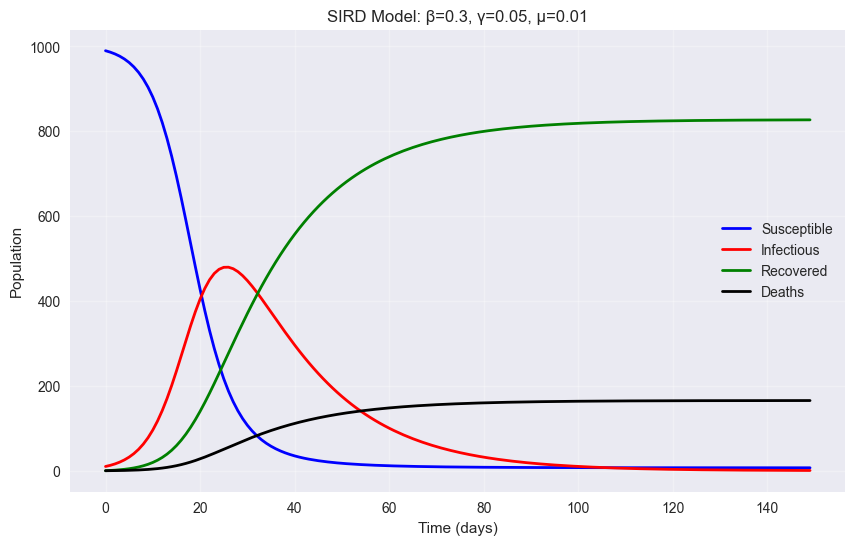

C:\Users\juras\AppData\Local\Temp\ipykernel_37032\1332535958.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, pd.DataFrame({


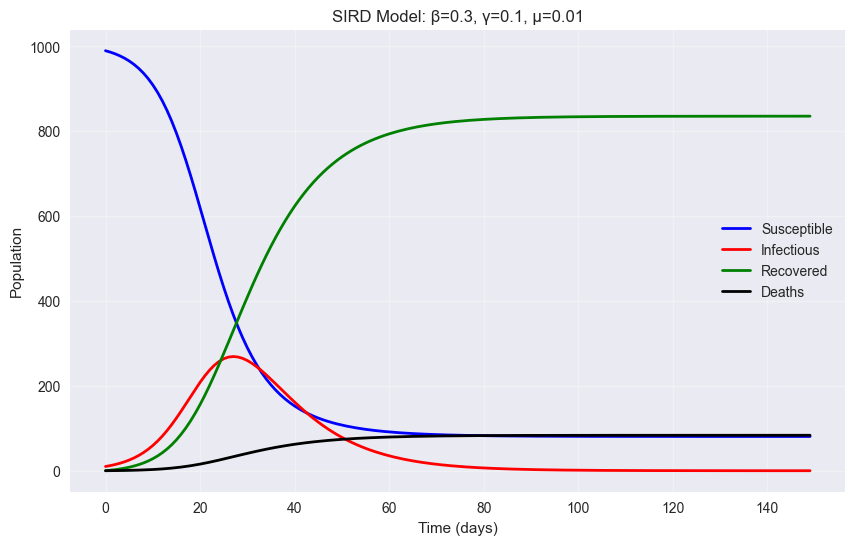

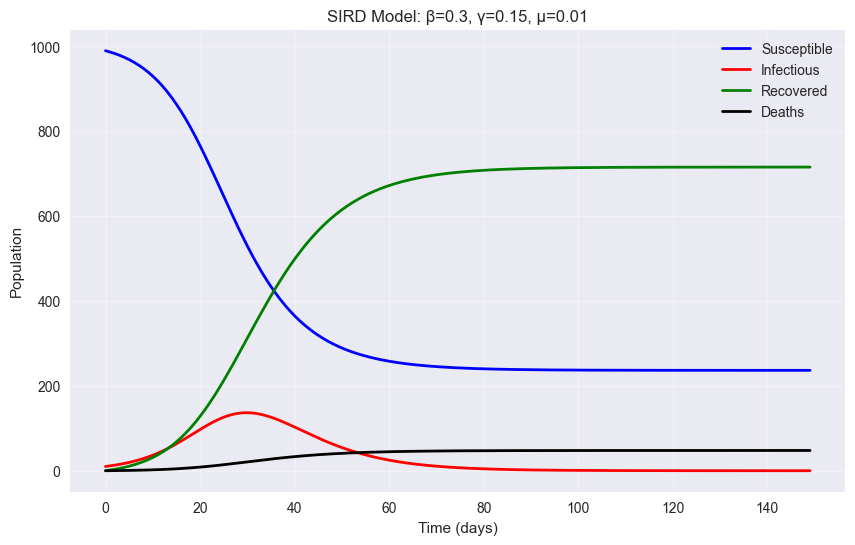

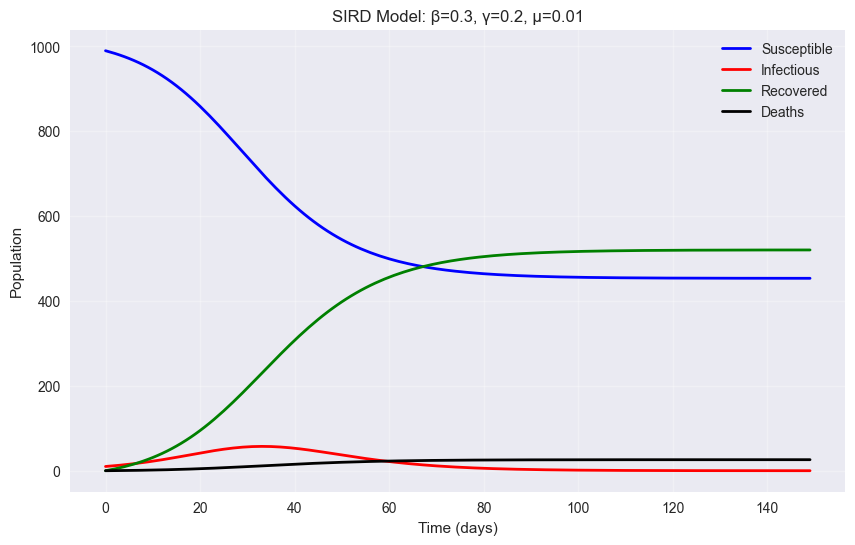

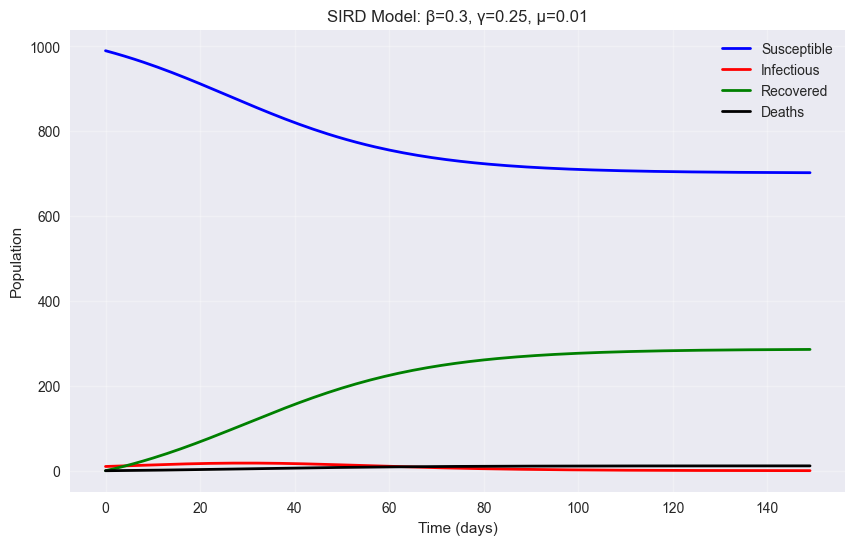

   gamma   R0  peak_infected peak_days  total_deaths
0   0.05  6.0     479.737984        26    165.413925
1   0.10  3.0     269.138176        27     83.572705
2   0.15  2.0     136.756407        30     47.712503
3   0.20  1.5      57.359889        33     26.019199
4   0.25  1.2      18.021355        30     11.436114


In [ ]:
results = analyze_recovery_rates(beta=0.3, mu=0.01, N=1000, I0=10, simulation_days=150)
print(results)


2.1 Scenario analysis
Use your function to compare two scenarios:

Scenario A - "High Transmission":

beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200
Scenario B - "Low Transmission":

beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200

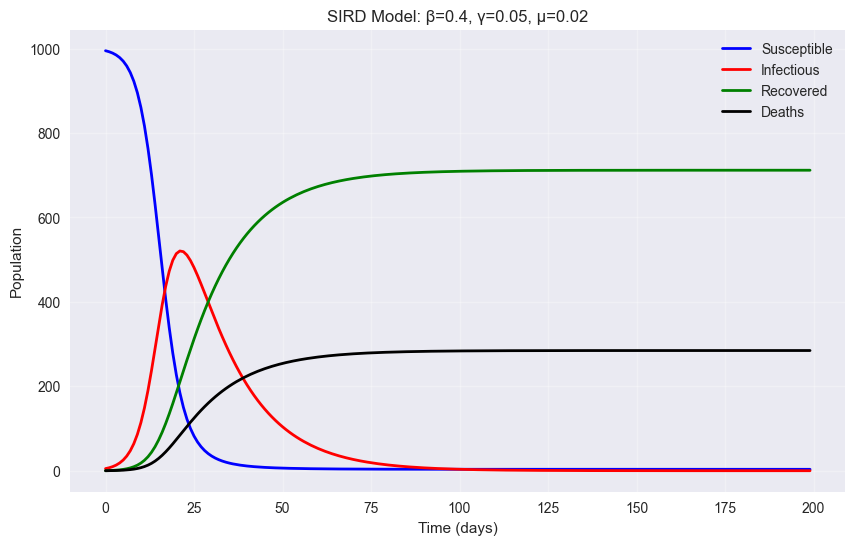

C:\Users\juras\AppData\Local\Temp\ipykernel_37032\1332535958.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, pd.DataFrame({


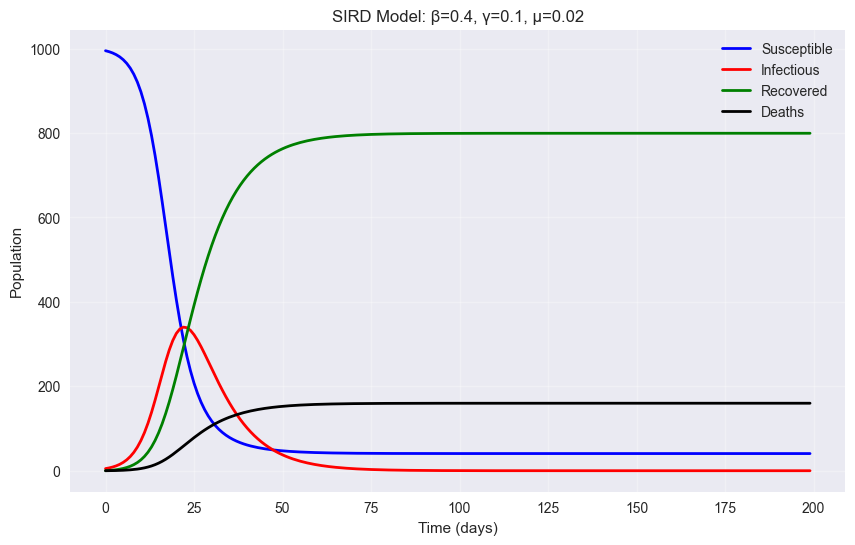

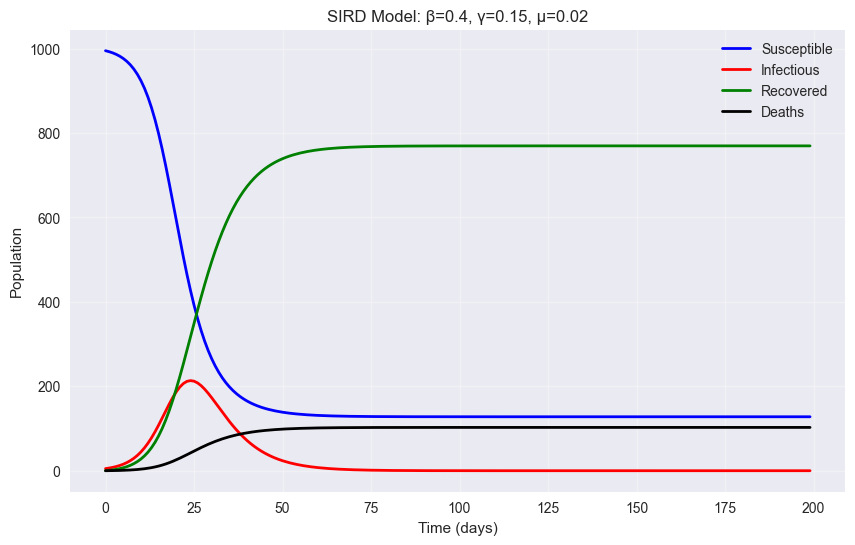

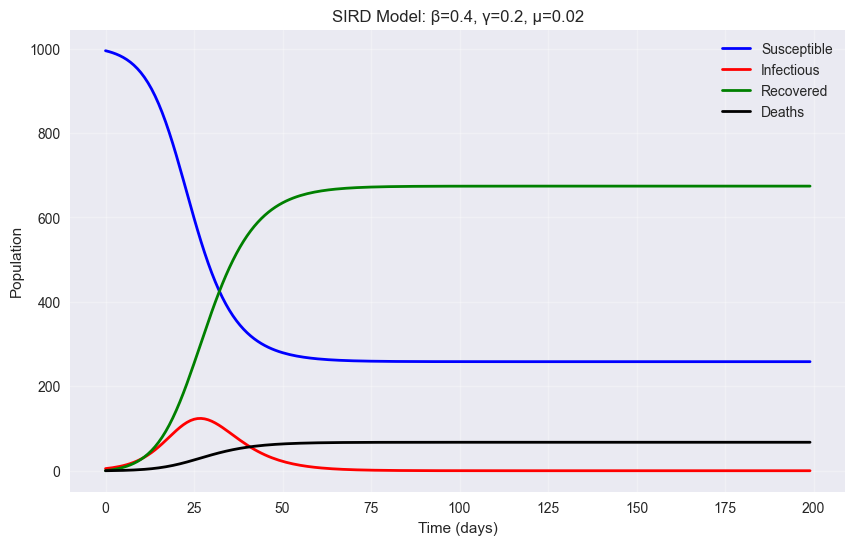

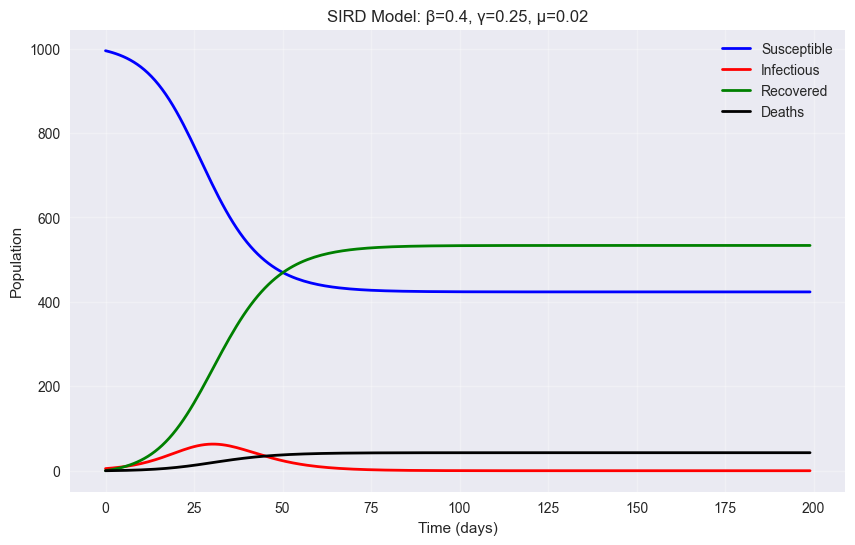

   gamma        R0  peak_infected peak_days  total_deaths
0   0.05  8.000000     520.582635        21    284.757361
1   0.10  4.000000     340.140583        22    159.892366
2   0.15  2.666667     213.465894        24    102.610885
3   0.20  2.000000     123.893909        27     67.423926
4   0.25  1.600000      63.051893        30     42.694003


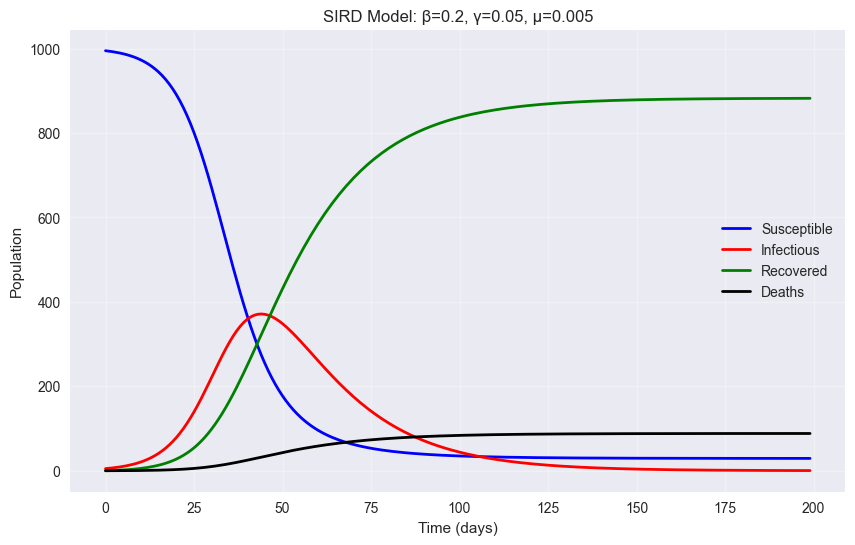

C:\Users\juras\AppData\Local\Temp\ipykernel_37032\1332535958.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, pd.DataFrame({


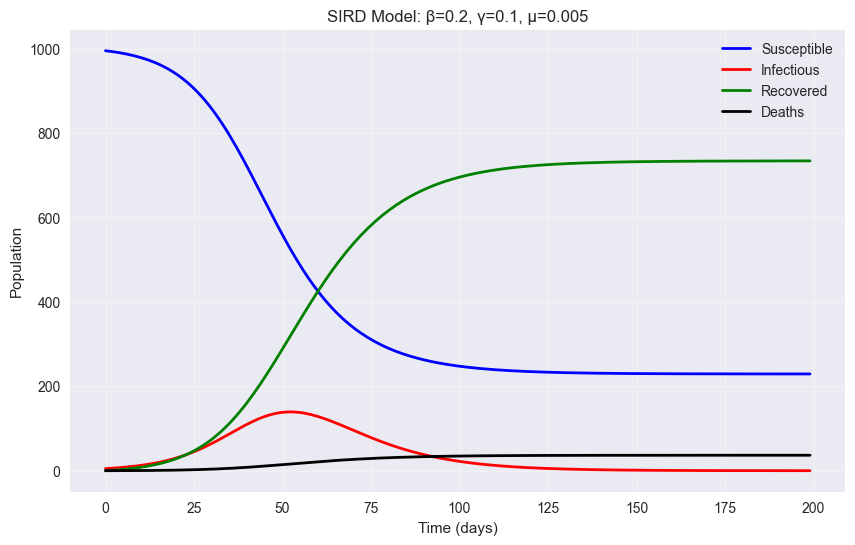

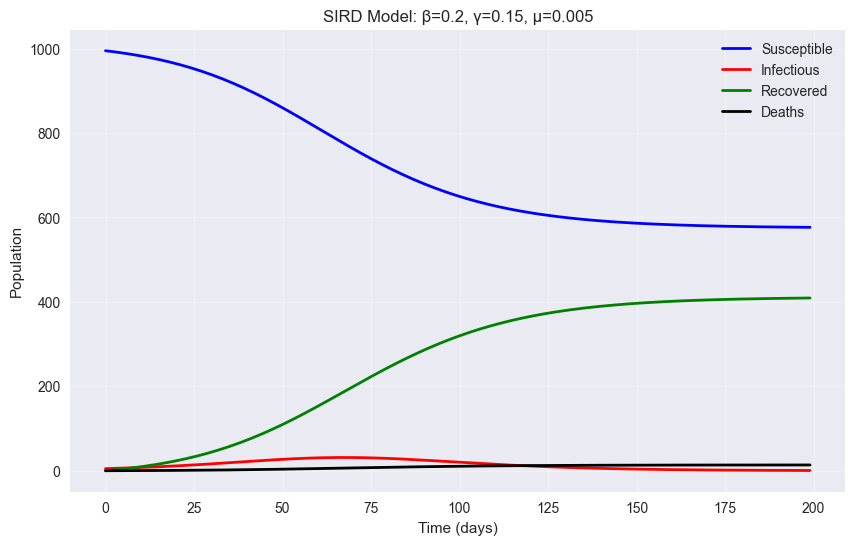

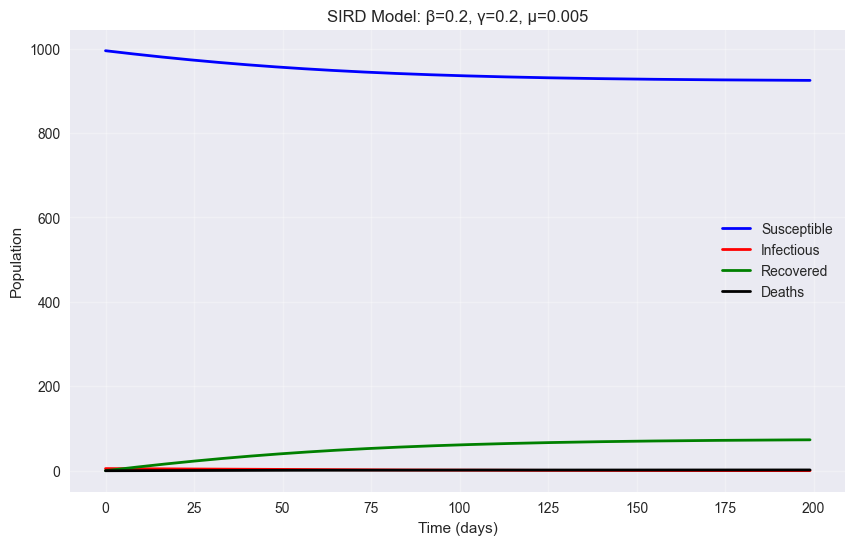

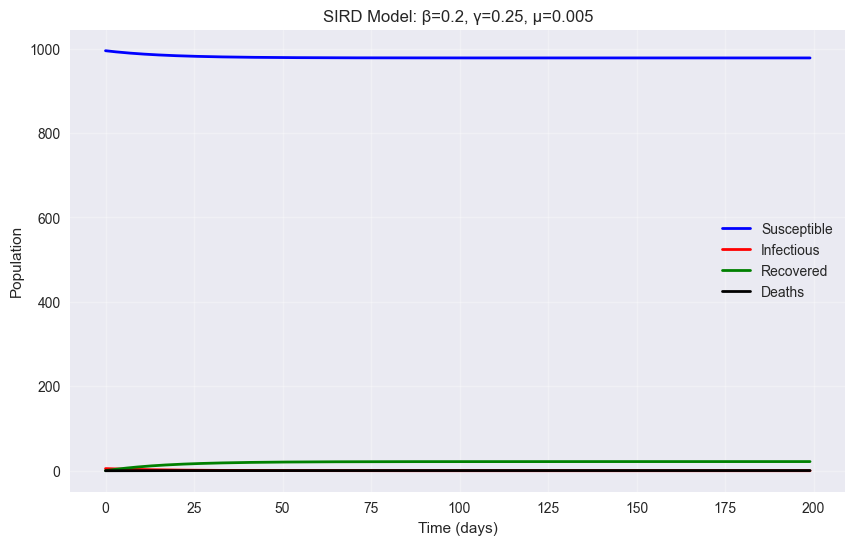

   gamma        R0  peak_infected peak_days  total_deaths
0   0.05  4.000000     371.356334        44     88.224137
1   0.10  2.000000     139.333450        52     36.699911
2   0.15  1.333333      31.340756        67     13.640017
3   0.20  1.000000       5.000000         0      1.831032
4   0.25  0.800000       5.000000         0      0.433166


In [ ]:
#scenario 1:
results1 = analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200)
print(results1)

#scenario 2:
results2 = analyze_recovery_rates(beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200)
print(results2)

Text(0.5, 1.0, 'Scenario 2: β=0.2, μ=0.005')

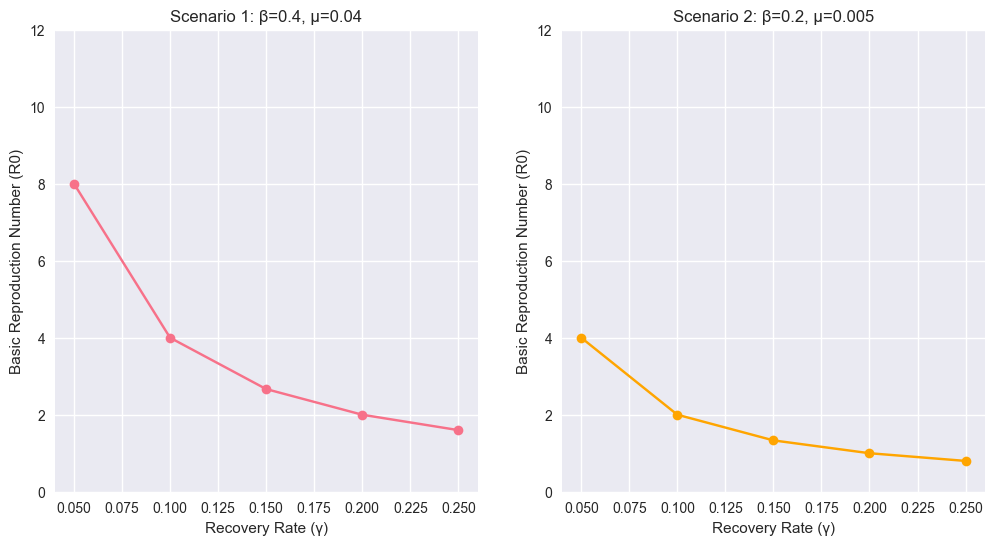

In [ ]:
#create a side by side comparison of the two scenarios
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(results1['gamma'], results1['R0'], marker='o')
plt.xlabel('Recovery Rate (γ)')
plt.ylabel('Basic Reproduction Number (R0)')
plt.ylim(0, 12)
plt.title('Scenario 1: β=0.4, μ=0.04')

plt.subplot(1, 2, 2)
plt.plot(results2['gamma'], results2['R0'], marker='o', color='orange')
plt.xlabel('Recovery Rate (γ)')
plt.ylabel('Basic Reproduction Number (R0)')
plt.ylim(0, 12)
plt.title('Scenario 2: β=0.2, μ=0.005')

Scenario 1 is worse, because the R0 is higher compared to scenario 1. For each gamma value the scenario one had more peak infected and multiple times more total deaths. When comparing the peak days, the scenarios 2 peak occurs later with a flatter curve, which is a good thing. Look back to covid and all the campaigns about flatening the curve. This is beneficial because the doctors will have less patients to treat at the same time and that can prevent even more deaths.